In [ ]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load the fake or real dataset from local file path
df = pd.read_csv("/content/sample_data/fake_or_real_news (1).csv")
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [ ]:
df.columns.tolist()

['Unnamed: 0', 'title', 'text', 'label']

In [ ]:
## check the missing values in each column of the dataframe
missing_val = df.isnull().sum()
print("Missing values per column:")
print(missing_val)

Missing values per column:
Unnamed: 0    0
title         0
text          0
label         0
dtype: int64


In [ ]:
#drop the unnamed column
df =df.drop('Unnamed: 0', axis=1)
df.head(5)

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [79]:
# value count of the label column
df['label'].value_counts()

,count
label,
REAL,3171
FAKE,3164


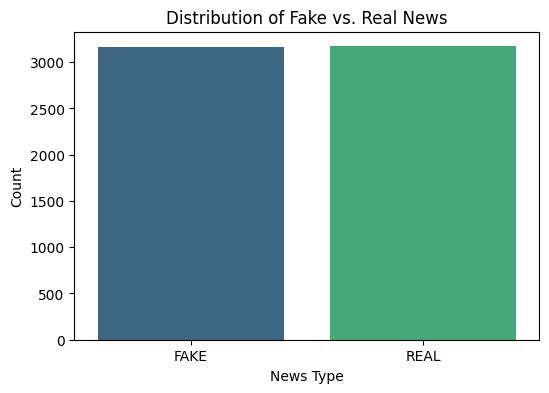

In [83]:
# Do countplot of the label column(Real or Fake)
#sns.countplot(data=df, x='label')
plt.figure(figsize=(6, 4))
sns.countplot(x='label', hue='label', data=df, palette='viridis')
plt.title('Distribution of Fake vs. Real News')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.show()

In [85]:
# install nlk library
!pip install nltk

In [ ]:
# import nlk library
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [86]:
# import these for Data preparation - text preprocessing
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [ ]:
#initialize the inbuilt stemmer
stemmer = PorterStemmer()

##using the lemmatizer
lemmatizer = WordNetLemmatizer()

In [ ]:

def preprocess(raw_text, flag):
    #removing special characters and digits
    sentence = re.sub("[^a-zA-Z]", " ", raw_text)

    #change sentence to lower case
    sentence = sentence.lower()

    #tokenize into words
    tokens = sentence.split()

    #removing stop words
    clean_tokens = [t for t in tokens if not t in stopwords.words('english')]

    #stemming/lemmatization
    if (flag=='stem'):
        clean_tokens = [stemmer.stem(word) for word in clean_tokens]
    else:
        clean_tokens = [lemmatizer.lemmatize(word) for word in clean_tokens]

    return pd.Series([" ".join(clean_tokens), len(clean_tokens)])

In [ ]:
# Apply preprocessing using lemmatization
df[['clean_text', 'word_count']] = df['text'].apply(lambda x: preprocess(x, 'lemma'))

# View result
df[['clean_text', 'word_count']].head()

,clean_text,word_count
0,daniel greenfield shillman journalism fellow f...,670
1,google pinterest digg linkedin reddit stumbleu...,240
2,u secretary state john f kerry said monday sto...,241
3,kaydee king kaydeeking november lesson tonight...,243
4,primary day new york front runner hillary clin...,178


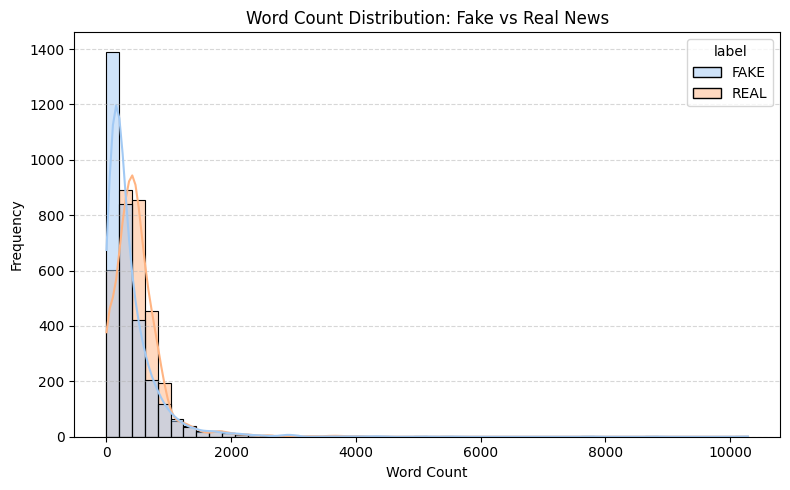

In [ ]:
# Plot word count distributions by label
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='word_count', hue='label', kde=True, bins=50, palette='pastel')
plt.title('Word Count Distribution: Fake vs Real News')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


The word count distribution plot shows the frequency of different word counts in both fake and real news articles.

In [ ]:
!pip install wordcloud


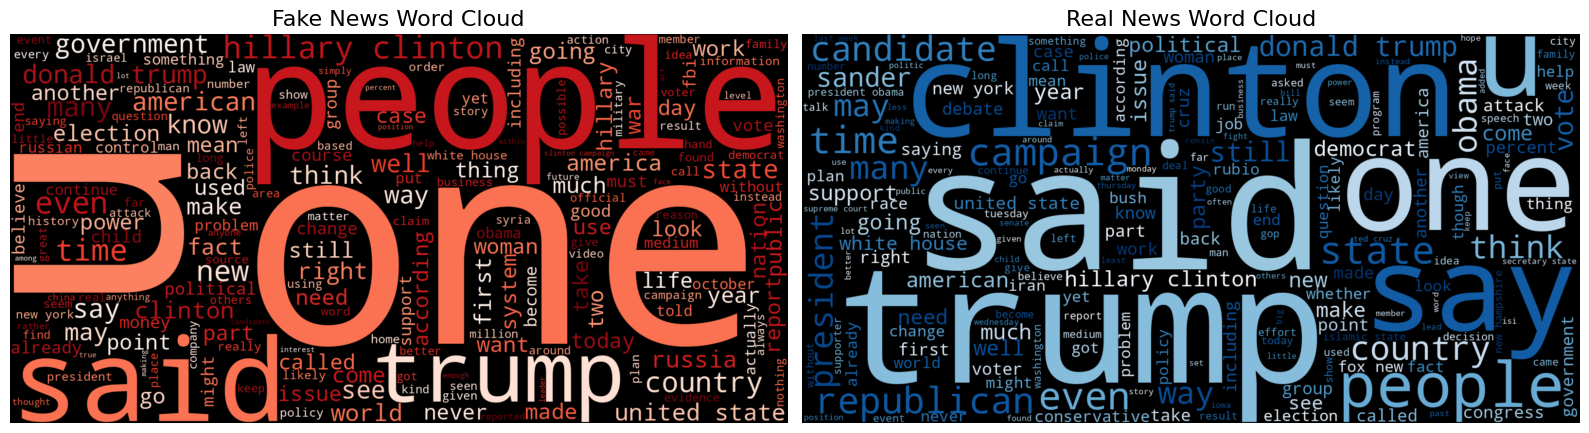

In [ ]:
from wordcloud import WordCloud

# Join all clean text by label
fake_text = " ".join(df[df['label'] == 'FAKE']['clean_text'])
real_text = " ".join(df[df['label'] == 'REAL']['clean_text'])

# Generate WordClouds
fake_wc = WordCloud(width=1600, height=800, background_color='black', colormap='Reds').generate(fake_text)
real_wc = WordCloud(width=1600, height=800, background_color='black', colormap='Blues').generate(real_text)

# Plot side-by-side
plt.figure(figsize=(16, 7))
plt.subplot(1, 2, 1)
plt.imshow(fake_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Fake News Word Cloud", fontsize=16)

plt.subplot(1, 2, 2)
plt.imshow(real_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Real News Word Cloud", fontsize=16)

plt.tight_layout()
plt.show()

These word cloud plots visualize the most frequent words in the text data, with the size of each word indicating its frequency.

The "Fake News Word Cloud" displays words that appear most often in fake news articles in your dataset, while the "Real News Word Cloud" does the same for real news articles.

By comparing the two word clouds, we can visually identify words that are more prominent in one category versus the other. This can reveal potential differences in vocabulary, topics, or writing styles between fake and real news.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# Transform clean text into TF-IDF features
X_tfidf = tfidf.fit_transform(df['clean_text'])

# Check shape
print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (6335, 5000)


In [ ]:
!pip install textblob
from textblob import TextBlob

In [ ]:
# Define sentiment extraction function
def get_sentiment(text):
    blob = TextBlob(text)
    return pd.Series([blob.polarity, blob.subjectivity])

# Apply it to your clean text
df[['polarity', 'subjectivity']] = df['clean_text'].apply(get_sentiment)

# Preview the result
df[['clean_text', 'polarity', 'subjectivity']].head()

,clean_text,polarity,subjectivity
0,daniel greenfield shillman journalism fellow f...,0.036808,0.547347
1,google pinterest digg linkedin reddit stumbleu...,0.036420,0.585802
2,u secretary state john f kerry said monday sto...,0.092083,0.316111
3,kaydee king kaydeeking november lesson tonight...,0.064556,0.460703
4,primary day new york front runner hillary clin...,0.267382,0.420441


# N-gram Analysis
To understand the most frequently used phrases in fake and real news, i conducted unigram, bigram, and trigram frequency analysis.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Filter dataframes (already done in previous step, but kept for completeness in this block)
df_fake = df[df['label'] == 'FAKE']
df_real = df[df['label'] == 'REAL']

# Unigram analysis
vectorizer_uni = CountVectorizer(ngram_range=(1, 1))

# Fake news unigrams
X_fake_uni = vectorizer_uni.fit_transform(df_fake['clean_text'])
fake_uni_counts = pd.Series(np.array(X_fake_uni.sum(axis=0)).flatten(), index=vectorizer_uni.get_feature_names_out()).sort_values(ascending=False)

# Real news unigrams
X_real_uni = vectorizer_uni.fit_transform(df_real['clean_text'])
real_uni_counts = pd.Series(np.array(X_real_uni.sum(axis=0)).flatten(), index=vectorizer_uni.get_feature_names_out()).sort_values(ascending=False)

# Print top 20 unigrams
print("Top 20 Unigrams - Fake News:")
print(fake_uni_counts.head(20))
print("\nTop 20 Unigrams - Real News:")
print(real_uni_counts.head(20))

# Bigram analysis
vectorizer_bi = CountVectorizer(ngram_range=(2, 2))

# Fake news bigrams
X_fake_bi = vectorizer_bi.fit_transform(df_fake['clean_text'])
fake_bi_counts = pd.Series(np.array(X_fake_bi.sum(axis=0)).flatten(), index=vectorizer_bi.get_feature_names_out()).sort_values(ascending=False)

# Real news bigrams
X_real_bi = vectorizer_bi.fit_transform(df_real['clean_text'])
real_bi_counts = pd.Series(np.array(X_real_bi.sum(axis=0)).flatten(), index=vectorizer_bi.get_feature_names_out()).sort_values(ascending=False)

# Print top 20 bigrams
print("\nTop 20 Bigrams - Fake News:")
print(fake_bi_counts.head(20))
print("\nTop 20 Bigrams - Real News:")
print(real_bi_counts.head(20))

# Trigram analysis
vectorizer_tri = CountVectorizer(ngram_range=(3, 3))

# Fake news trigrams
X_fake_tri = vectorizer_tri.fit_transform(df_fake['clean_text'])
fake_tri_counts = pd.Series(np.array(X_fake_tri.sum(axis=0)).flatten(), index=vectorizer_tri.get_feature_names_out()).sort_values(ascending=False)

# Real news trigrams
X_real_tri = vectorizer_tri.fit_transform(df_real['clean_text'])
real_tri_counts = pd.Series(np.array(X_real_tri.sum(axis=0)).flatten(), index=vectorizer_tri.get_feature_names_out()).sort_values(ascending=False)

# Print top 20 trigrams
print("\nTop 20 Trigrams - Fake News:")
print(fake_tri_counts.head(20))
print("\nTop 20 Trigrams - Real News:")
print(real_tri_counts.head(20))

Top 20 Unigrams - Fake News:
clinton       7176
trump         6773
people        5557
one           5451
state         5268
would         4923
hillary       4602
time          4122
year          4108
said          4009
american      3770
election      3661
new           3524
like          3398
world         3217
also          3195
government    3116
even          2929
war           2887
president     2791
dtype: int64

Top 20 Unigrams - Real News:
said          17203
trump         15732
clinton       10897
state         10181
republican     8194
would          7858
one            6946
president      6341
people         6320
campaign       6027
obama          5972
year           5928
new            5809
time           5216
say            5130
party          5105
also           5030
american       4612
candidate      4486
could          4055
dtype: int64

Top 20 Bigrams - Fake News:
hillary clinton          2497
donald trump             1771
united state             1442
white house     

“Common fake news unigrams include emotionally charged words like ‘shocking’, ‘breaking’”

“Real news tends to use formal or topic-specific terms like ‘official’, ‘president’”

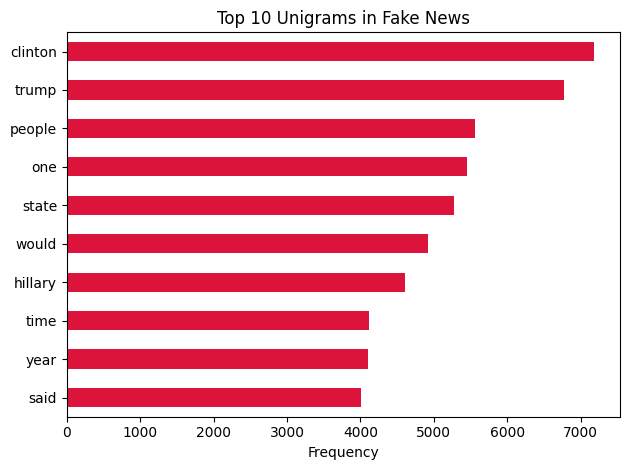

In [ ]:
# Plot top 10 fake unigrams
fake_uni_counts.head(10).plot(kind='barh', color='crimson')
plt.title('Top 10 Unigrams in Fake News')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Based on the "Top 10 Unigrams in Fake News" plot, the most frequent single words in the fake news articles in the dataset are: 'clinton', 'trump', 'people', 'one', 'state', 'would', 'hillary', 'time', 'year', and 'said'. This suggests these terms are highly prevalent in the fake news content.

# Modeling using Latent Dirichlet Allocation (LDA)

I applied LDA separately to FAKE and REAL news articles to identify dominant topics and themes within each category.


In [87]:
from sklearn.decomposition import LatentDirichletAllocation

# Initialize LDA models
n_topics = 10
lda_fake = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda_real = LatentDirichletAllocation(n_components=n_topics, random_state=42)

# Apply TF-IDF only for fake and real news separately
tfidf_fake = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_fake_tfidf = tfidf_fake.fit_transform(df_fake['clean_text'])

tfidf_real = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_real_tfidf = tfidf_real.fit_transform(df_real['clean_text'])

# Fit LDA to fake and real news TF-IDF matrices
lda_fake.fit(X_fake_tfidf)
lda_real.fit(X_real_tfidf)

# Function to print top words for each topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = "Topic #%d: " % topic_idx
        message += " ".join([feature_names[i]
                              for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)
    print()

# Get feature names
fake_feature_names = tfidf_fake.get_feature_names_out()
real_feature_names = tfidf_real.get_feature_names_out()

# Print top topics for fake news topics
print("Top topics in Fake News:")
print_top_words(lda_fake, fake_feature_names, 10)

# Print top topics for real news topics
print("Top topics in Real News:")
print_top_words(lda_real, real_feature_names, 10)

Top topics in Fake News:
Topic #0: galacticconnection galacticconnection com com comment wmw admin wmw add conversation http facebook
Topic #1: scrabble rius microcephaly zika virus predator air force aircraft air force mosquito
Topic #2: tb brooklyn screening breitbart endorsed cleared clinical utah infection combination
Topic #3: text block text utm comment com result page generated infowars italic text
Topic #4: help fight moreno amy moreno amy pumpkin guest juror like share megyn share story
Topic #5: people one trump said year state russia would war world
Topic #6: hatch act time warner warner merger white helmet dress figure support see reid
Topic #7: clinton trump hillary fbi email election hillary clinton campaign investigation comey
Topic #8: lesley tibet lesley stahl stahl mcmahon morris haganah great britain convention ethnic cleansing
Topic #9: recovery chart since day subpoena brock mainly david duke lynch kaine

Top topics in Real News:
Topic #0: trump clinton said republ

In [102]:
# ✅ Download the necessary resources
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [90]:
from nltk import pos_tag, word_tokenize
from collections import Counter

# POS tagging function
def get_pos_tags(text):
    if isinstance(text, str):
        tokens = word_tokenize(text)
        return pos_tag(tokens)
    return []

# Apply POS tagging to clean_text column
df['pos_tags'] = df['clean_text'].apply(get_pos_tags)

# Function to count POS tag frequencies
def count_pos_tags(pos_tag_list):
    return Counter(tag for word, tag in pos_tag_list)

# Count POS tags by label
fake_pos_counts = Counter()
for tags in df[df['label'] == 'FAKE']['pos_tags']:
    fake_pos_counts.update(count_pos_tags(tags))

real_pos_counts = Counter()
for tags in df[df['label'] == 'REAL']['pos_tags']:
    real_pos_counts.update(count_pos_tags(tags))

# Convert to DataFrames for comparison
fake_pos_df = pd.DataFrame.from_dict(fake_pos_counts, orient='index', columns=['count']).sort_values(by='count', ascending=False)
real_pos_df = pd.DataFrame.from_dict(real_pos_counts, orient='index', columns=['count']).sort_values(by='count', ascending=False)

# Display results
print("Top 20 POS Tag Counts - Fake News:")
print(fake_pos_df.head(20))

print("\nTop 20 POS Tag Counts - Real News:")
print(real_pos_df.head(20))


Top 20 POS Tag Counts - Fake News:
      count
NN   557256
JJ   257523
RB    68182
VBD   64085
VBG   52082
VBP   35258
VBN   31071
VB    26733
NNS   24006
IN    22766
CD    13338
MD    12265
VBZ    9107
JJS    4246
JJR    3908
DT     2851
NNP    2654
RBR    2445
FW     2234
CC      908

Top 20 POS Tag Counts - Real News:
      count
NN   722078
JJ   321009
VBD  102439
RB    84101
VBG   69697
VBP   42881
VBN   39583
VB    35080
IN    29340
NNS   27109
CD    19548
MD    17415
VBZ    9507
JJR    6275
JJS    5477
RBR    3940
DT     3515
NNP    2472
FW     1849
RP     1385


Top 10 POS Tag Percentages - Fake News:
NN     46.601143
JJ     21.535643
RB      5.701794
VBD     5.359178
VBG     4.355414
VBP     2.948489
VBN     2.598346
VB      2.235576
NNS     2.007528
IN      1.903832
Name: percentage, dtype: float64

Top 10 POS Tag Percentages - Real News:
NN     46.642160
JJ     20.735368
VBD     6.616981
RB      5.432449
VBG     4.502032
VBP     2.769870
VBN     2.556838
VB      2.265970
IN      1.895198
NNS     1.751088
Name: percentage, dtype: float64


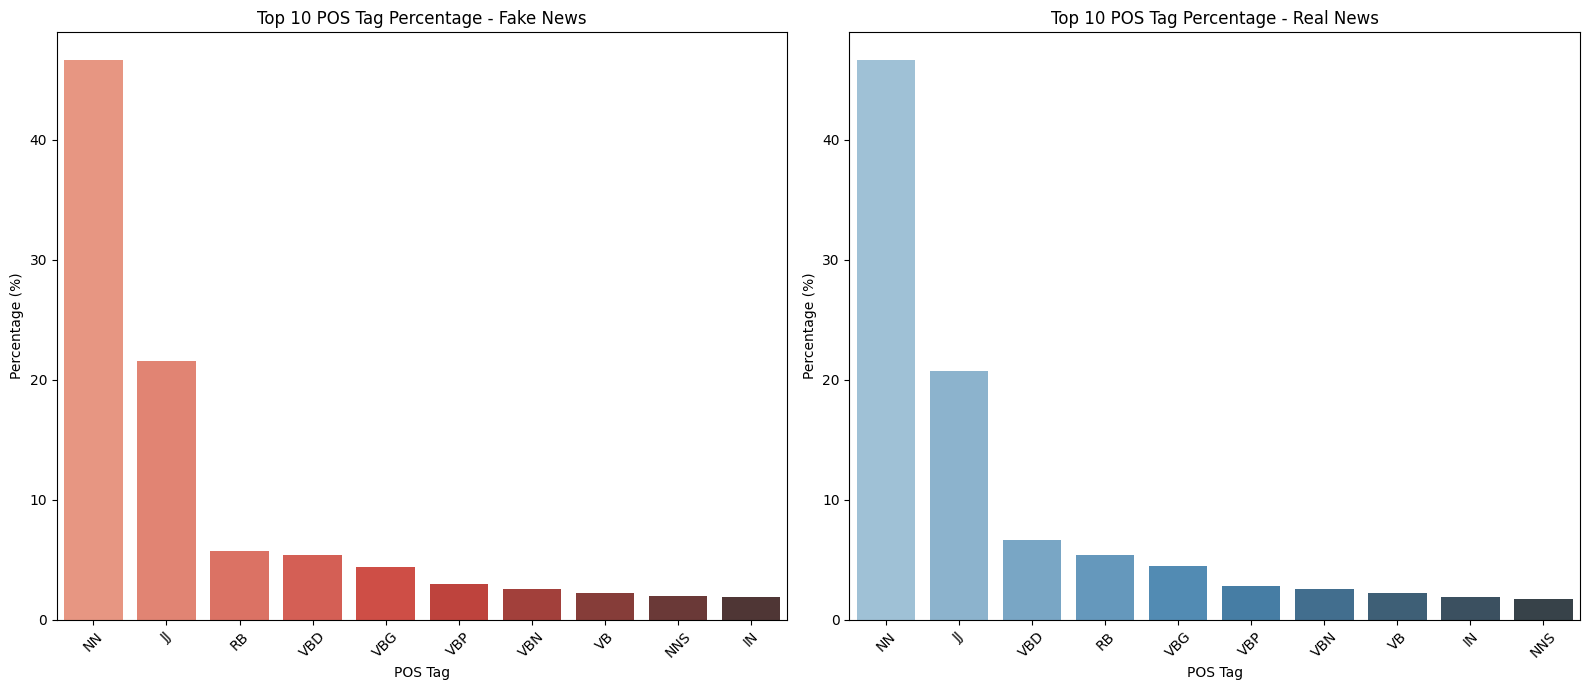

In [91]:
# Calculate total POS tags for normalization
total_fake_tags = fake_pos_df['count'].sum()
total_real_tags = real_pos_df['count'].sum()

# Calculate percentages
fake_pos_df['percentage'] = (fake_pos_df['count'] / total_fake_tags) * 100
real_pos_df['percentage'] = (real_pos_df['count'] / total_real_tags) * 100

# Display top 10 percentages
print("Top 10 POS Tag Percentages - Fake News:")
print(fake_pos_df['percentage'].head(10))

print("\nTop 10 POS Tag Percentages - Real News:")
print(real_pos_df['percentage'].head(10))

# Visualize top 10 POS tags by percentage
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Fake news
sns.barplot(x=fake_pos_df['percentage'].head(10).index, y=fake_pos_df['percentage'].head(10).values, ax=axes[0], palette='Reds_d', hue=fake_pos_df['percentage'].head(10).index, legend=False)
axes[0].set_title('Top 10 POS Tag Percentage - Fake News')
axes[0].set_xlabel('POS Tag')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=45)

# Real news
sns.barplot(x=real_pos_df['percentage'].head(10).index, y=real_pos_df['percentage'].head(10).values, ax=axes[1], palette='Blues_d', hue=real_pos_df['percentage'].head(10).index, legend=False)
axes[1].set_title('Top 10 POS Tag Percentage - Real News')
axes[1].set_xlabel('POS Tag')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

To capture the writing style of fake versus real news, i created a new feature: `adj_ratio`, which measures the proportion of adjectives in each article. Since fake news often uses emotional or exaggerated language, this feature may help improve model performance.


In [92]:
from collections import Counter

# Function to calculate adjective ratio
def extract_adj_ratio(pos_tags):
    total = len(pos_tags)
    count = Counter(tag for word, tag in pos_tags)
    return count['JJ'] / total if total else 0

# Create a new column
df['adj_ratio'] = df['pos_tags'].apply(extract_adj_ratio)

# Check the new feature
df[['clean_text', 'adj_ratio']].head()

,clean_text,adj_ratio
0,daniel greenfield shillman journalism fellow f...,0.220896
1,google pinterest digg linkedin reddit stumbleu...,0.150000
2,u secretary state john f kerry said monday sto...,0.232365
3,kaydee king kaydeeking november lesson tonight...,0.238683
4,primary day new york front runner hillary clin...,0.213483


In [93]:
from scipy.sparse import hstack

#  TF-IDF matrix from clean_text
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

#  Get sentiment features (polarity, subjectivity)
sentiment_features = np.array(df[['polarity', 'subjectivity']])

#  Get adj_ratio feature
adj_feature = np.array(df['adj_ratio']).reshape(-1, 1)

#  Combine all features: TF-IDF + sentiment + adj_ratio
X_combined = hstack([X_tfidf, sentiment_features, adj_feature])

#  Encode labels (REAL = 0, FAKE = 1) — keep it consistent with your earlier work
df['label_encoded'] = df['label'].map({'FAKE': 1, 'REAL': 0})
y = df['label_encoded']



In [94]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, stratify=y, random_state=42
)
# Confirm dimensions
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5068, 5003)
X_test: (1267, 5003)
y_train: (5068,)
y_test: (1267,)


In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
print(" Logistic Regression Results (TF-IDF + Sentiment + Adj Ratio):")
print(classification_report(y_test, y_pred_lr, target_names=['REAL', 'FAKE']))
print(" Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

 Logistic Regression Results (TF-IDF + Sentiment + Adj Ratio):
              precision    recall  f1-score   support

        REAL       0.93      0.90      0.91       634
        FAKE       0.90      0.94      0.92       633

    accuracy                           0.92      1267
   macro avg       0.92      0.92      0.92      1267
weighted avg       0.92      0.92      0.92      1267

 Accuracy: 0.9163378058405682

 Confusion Matrix:
[[568  66]
 [ 40 593]]


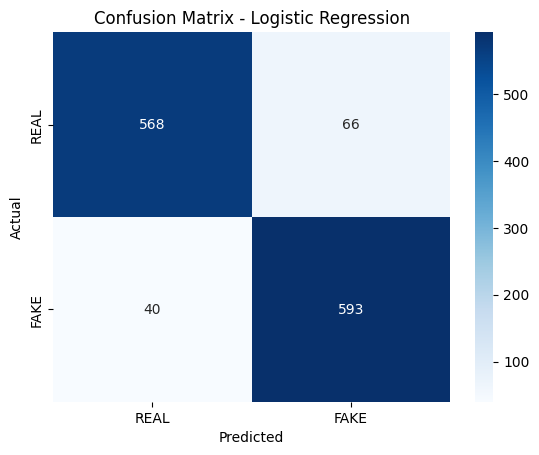

In [96]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [97]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Results (TF-IDF + Sentiment + Adj Ratio):")
print(classification_report(y_test, y_pred_rf, target_names=['REAL', 'FAKE']))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results (TF-IDF + Sentiment + Adj Ratio):
              precision    recall  f1-score   support

        REAL       0.92      0.91      0.92       634
        FAKE       0.91      0.92      0.92       633

    accuracy                           0.92      1267
   macro avg       0.92      0.92      0.92      1267
weighted avg       0.92      0.92      0.92      1267

Accuracy: 0.9163378058405682

 Confusion Matrix:
[[576  58]
 [ 48 585]]


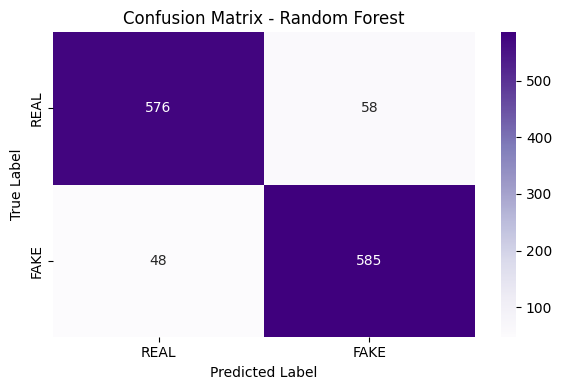

In [98]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot the matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=["REAL", "FAKE"],
            yticklabels=["REAL", "FAKE"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

In [99]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Train HistGradientBoostingClassifier
hgb_model = HistGradientBoostingClassifier(random_state=42)
hgb_model.fit(X_train.toarray(), y_train)  # convert to dense

# Predict
y_pred_hgb = hgb_model.predict(X_test.toarray())

# Evaluate
print("HistGradientBoosting Results (TF-IDF + Sentiment + Adj Ratio):")
print(classification_report(y_test, y_pred_hgb, target_names=['REAL', 'FAKE']))
print("Accuracy:", accuracy_score(y_test, y_pred_hgb))
print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_hgb))

HistGradientBoosting Results (TF-IDF + Sentiment + Adj Ratio):
              precision    recall  f1-score   support

        REAL       0.93      0.92      0.93       634
        FAKE       0.92      0.93      0.93       633

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267

Accuracy: 0.9265982636148382

 Confusion Matrix:
[[584  50]
 [ 43 590]]


In [100]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
import numpy as np

# Rebuild the combined feature matrix
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])
sentiment_features = np.array(df[['polarity', 'subjectivity']])
adj_feature = np.array(df['adj_ratio']).reshape(-1, 1)

X = hstack([X_tfidf, sentiment_features, adj_feature])
y = df['label'].map({'FAKE': 1, 'REAL': 0})

# Convert to dense format for SVM
X_dense = X.toarray()

# Split data
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_dense, y, test_size=0.2, stratify=y, random_state=42
)

# Train SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_svm, y_train_svm)

# Predict and evaluate
y_pred_svm = svm_model.predict(X_test_svm)

print("SVM Results (TF-IDF + Sentiment + Adj Ratio):")
print(classification_report(y_test_svm, y_pred_svm, target_names=['REAL', 'FAKE']))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_svm, y_pred_svm))

SVM Results (TF-IDF + Sentiment + Adj Ratio):
              precision    recall  f1-score   support

        REAL       0.94      0.93      0.94       634
        FAKE       0.93      0.94      0.94       633

    accuracy                           0.94      1267
   macro avg       0.94      0.94      0.94      1267
weighted avg       0.94      0.94      0.94      1267

Accuracy: 0.936069455406472

Confusion Matrix:
[[591  43]
 [ 38 595]]


In [101]:
# Model performance summary
model_results = {
    'Model': ['SVM', 'HistGB', 'RandomForest', 'LogReg'],
    'Accuracy': [0.9361, 0.9266, 0.9163, 0.9163],
    'Precision': [0.94, 0.93, 0.92, 0.91],
    'Recall': [0.94, 0.93, 0.92, 0.92],
    'F1-Score': [0.94, 0.93, 0.92, 0.92]
}

# Create and display DataFrame
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print(results_df)


          Model  Accuracy  Precision  Recall  F1-Score
0           SVM    0.9361       0.94    0.94      0.94
1        HistGB    0.9266       0.93    0.93      0.93
2  RandomForest    0.9163       0.92    0.92      0.92
3        LogReg    0.9163       0.91    0.92      0.92


 Here are some Key Insights from the Model and Dataset
Based on the exploratory data analysis and the model results

Balanced Dataset: The dataset has a nearly equal distribution of fake and real news articles (df['label'].value_counts() shows 3171 REAL and 3164 FAKE), which is beneficial for training classification models and avoids bias towards one class.
Text Preprocessing Effectiveness: The text preprocessing steps (cleaning, tokenization, stop word removal, lemmatization) were crucial in preparing the text data for feature extraction and modeling.
Feature Importance: The combination of TF-IDF features, sentiment features (polarity and subjectivity), and the adjective ratio feature proved to be effective in building models that can differentiate between fake and real news. The adj_ratio feature, specifically designed to capture writing style, likely contributed to the models' performance, supporting the idea that fake news might use more emotional or exaggerated language.
N-gram Differences: The n-gram analysis revealed differences in the most frequent words and phrases used in fake versus real news. This indicates that there are distinct linguistic patterns that can be leveraged for classification.
POS Tagging Insights: The Part-of-Speech tagging analysis showed the distribution of different word types in fake and real news. While the overall distributions might be similar for the most frequent tags, subtle differences in the proportions of certain tags (like adjectives) can be informative.
Model Choice: SVM performed best on this dataset with the engineered features. This suggests that a linear classifier with a suitable kernel can effectively separate the data in the feature space. HistGradientBoosting also showed strong performance, indicating the potential of tree-based ensemble methods.

In Conclusion
The analysis demonstrates that it is possible to build effective models for fake news detection using a combination of TF-IDF, sentiment analysis, and linguistic features like the adjective ratio. The SVM model achieved the highest accuracy, suggesting its suitability for this task with the engineered features. Further investigation into misclassifications and potentially exploring more advanced text representation techniques or deep learning models could lead to even better performance. The key insights from the dataset highlight the importance of text preprocessing, feature engineering, and understanding the linguistic characteristics that differentiate fake from real news.